In [1]:
import pandas as pd
df = pd.read_csv("financial_fraud_detection_dataset.csv")   
 

In [2]:
df.head(20)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601
5,T100005,2023-11-20T17:49:27.940971,ACC581141,ACC249811,58.77,transfer,entertainment,Berlin,atm,False,NaN,NaN,-1.63,19,0.40,UPI,112.70.252.46,D1790481
6,T100006,2023-11-11T11:15:41.359248,ACC757924,ACC267753,59.51,payment,travel,Dubai,pos,False,NaN,NaN,-2.62,1,0.68,UPI,58.136.174.57,D5924115
7,T100007,2023-06-09T06:32:36.945101,ACC103402,ACC857168,29.79,transfer,entertainment,London,atm,False,NaN,NaN,-0.48,5,0.37,ACH,82.0.165.250,D1326765
8,T100008,2023-02-11T06:57:40.585720,ACC972064,ACC945964,16.00,transfer,utilities,New York,web,False,NaN,NaN,0.99,3,0.98,card,64.65.243.84,D5446912
9,T100009,2023-07-13T09:25:20.560022,ACC543692,ACC322086,203.05,withdrawal,grocery,Dubai,atm,False,NaN,NaN,0.59,17,0.45,UPI,126.115.32.173,D1352896


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [4]:
 
categorical_cols = [
    'transaction_type', 'merchant_category',
    'location', 'device_used', 'fraud_type',
    'payment_channel'
]

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts()[:10])   
    print("\n")


--- transaction_type ---
transaction_type
deposit       1250593
payment       1250438
transfer      1250334
withdrawal    1248635
Name: count, dtype: int64


--- merchant_category ---
merchant_category
retail           626319
travel           625656
restaurant       625483
entertainment    625332
grocery          624954
other            624589
utilities        624086
online           623581
Name: count, dtype: int64


--- location ---
location
Tokyo        625994
New York     625354
Singapore    625313
Berlin       625289
Sydney       625125
Toronto      624349
Dubai        624320
London       624256
Name: count, dtype: int64


--- device_used ---
device_used
mobile    1251131
web       1250071
atm       1249640
pos       1249158
Name: count, dtype: int64


--- fraud_type ---
fraud_type
card_not_present    179553
Name: count, dtype: int64


--- payment_channel ---
payment_channel
wire_transfer    1251219
ACH              1250241
card             1249693
UPI              1248847
Name: c

In [5]:
#count of unique 
high_cardinality = ['sender_account', 'receiver_account', 'ip_address', 'device_hash']

for col in high_cardinality:
    print(col, df[col].nunique())


sender_account 896513
receiver_account 896639
ip_address 4997068
device_hash 3835723


In [6]:
# nulls per column
df.isna().sum()         


transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [7]:
df.describe()   

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01
std,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01
min,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01
50%,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01
75%,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01
max,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00


Counts:
is_fraud
False    4820447
True      179553
Name: count, dtype: int64

Percentages:
is_fraud
False    96.40894
True      3.59106
Name: proportion, dtype: float64


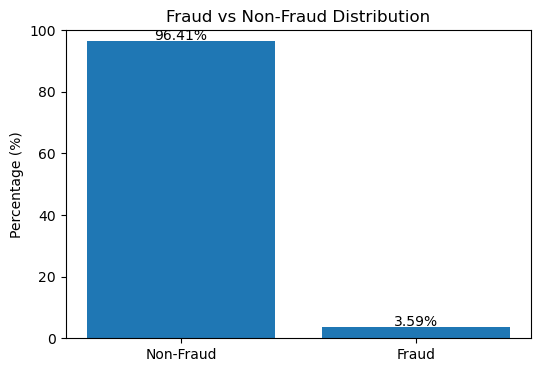

In [8]:
import matplotlib.pyplot as plt
#Class balance
df['is_fraud'].value_counts(normalize=True)  # percentage of each class
 

# 1) Counts and percentages
counts = df['is_fraud'].value_counts()
percentages = df['is_fraud'].value_counts(normalize=True) * 100

print("Counts:")
print(counts)
print("\nPercentages:")
print(percentages)

# 2) Bar chart  
plt.figure(figsize=(6,4))
x_labels = ['Non-Fraud', 'Fraud']   
y_values = [percentages[False], percentages[True]]   

plt.bar(x_labels, y_values)
plt.ylabel('Percentage (%)')
plt.title('Fraud vs Non-Fraud Distribution')

# Add percentage labels on top of bars
for i, v in enumerate(y_values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.ylim(0, 100)
plt.show()


## Mimicking real-time arrival into Kafka

In [1]:
import pandas as pd

df = pd.read_csv("financial_fraud_detection_dataset.csv")
# Sort by timestamp column
df = df.sort_values("timestamp")
# Save sorted version
df.to_csv("financial_fraud_detection_dataset_sorted.csv", index=False)

In [2]:
df.head(1000000)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
4883224,T4983224,2023-01-01T00:09:26.241974,ACC259476,ACC189392,12.25,transfer,grocery,Dubai,atm,False,NaN,-7559.966086,-0.32,2,0.96,UPI,89.75.248.198,D9764559
14745,T114745,2023-01-01T00:11:36.452582,ACC478421,ACC105006,1347.27,deposit,travel,Sydney,mobile,False,NaN,NaN,-0.68,5,0.67,UPI,108.75.191.104,D2292342
2901064,T3001064,2023-01-01T00:12:48.028557,ACC830612,ACC593266,20.79,payment,travel,Tokyo,web,False,NaN,-4568.663237,0.14,8,0.42,wire_transfer,215.139.243.78,D9777735
548800,T648800,2023-01-01T00:21:19.560899,ACC647991,ACC371308,740.73,deposit,utilities,Berlin,mobile,False,NaN,NaN,-2.09,20,0.86,UPI,126.146.190.250,D4372592
3417687,T3517687,2023-01-01T00:23:15.259766,ACC984405,ACC167110,228.67,deposit,grocery,Dubai,mobile,False,NaN,-48.738700,0.16,18,0.82,UPI,131.27.227.151,D3545707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3521981,T3621981,2023-03-15T12:50:32.038568,ACC452660,ACC342964,8.50,transfer,utilities,Sydney,mobile,False,NaN,-2597.530327,-0.72,15,0.24,UPI,136.114.246.29,D4049651
2162118,T2262118,2023-03-15T12:50:41.447214,ACC512842,ACC277447,1511.76,deposit,entertainment,Toronto,atm,False,NaN,438.734424,1.16,1,0.40,wire_transfer,87.145.135.177,D4732542
3200170,T3300170,2023-03-15T12:50:42.290853,ACC208166,ACC296237,415.97,withdrawal,travel,New York,mobile,False,NaN,-708.717691,0.03,9,0.12,wire_transfer,27.62.83.248,D4747519
3757178,T3857178,2023-03-15T12:50:43.727176,ACC301028,ACC626039,29.82,withdrawal,online,Singapore,pos,False,NaN,-3483.419624,0.12,5,0.15,ACH,157.34.67.1,D1697159


In [3]:
# Fraud sender repetition
fraud_senders = df[df["is_fraud"] == True]

sender_freq = (
    fraud_senders
    .groupby("sender_account")
    .size()
    .reset_index(name="fraud_tx_count")
)

sender_freq["fraud_tx_count"].describe()


count    161974.000000
mean          1.108530
std           0.336377
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           7.000000
Name: fraud_tx_count, dtype: float64

In [4]:
import pandas as pd

# 1) Get the list of "bad senders" = senders who have at least 1 fraud tx
bad_senders = df.loc[df["is_fraud"] == True, "sender_account"].dropna().unique()

# 2) Keep ALL transactions for those bad senders (fraud + non-fraud)
bad_sender_all_tx = df[df["sender_account"].isin(bad_senders)].copy()

# 3) Count fraud and non-fraud per sender
per_sender_counts = (
    bad_sender_all_tx
    .groupby(["sender_account", "is_fraud"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Make column names clear (depends on True/False columns existing)
per_sender_counts = per_sender_counts.rename(columns={
    True: "fraud_tx_count",
    False: "nonfraud_tx_count"
})

# 4) Add totals + fraud rate
per_sender_counts["total_tx"] = per_sender_counts["fraud_tx_count"] + per_sender_counts["nonfraud_tx_count"]
per_sender_counts["fraud_rate"] = per_sender_counts["fraud_tx_count"] / per_sender_counts["total_tx"]

per_sender_counts.head(10)


is_fraud,sender_account,nonfraud_tx_count,fraud_tx_count,total_tx,fraud_rate
0,ACC100005,8,1,9,0.111111
1,ACC100009,7,1,8,0.125000
2,ACC100010,5,1,6,0.166667
3,ACC100012,8,1,9,0.111111
4,ACC100027,9,1,10,0.100000
5,ACC100039,4,2,6,0.333333
6,ACC100051,5,1,6,0.166667
7,ACC100054,6,2,8,0.250000
8,ACC100055,4,1,5,0.200000
9,ACC100068,6,1,7,0.142857


In [3]:

"""
in all pipline : What happens exactly
                     1. producer is sending messages every 0.01 seconds(this the code do this step ),100 messages per second
                     2. Kafka stores them in the topic transactions_raw
                     3. Even if NO consumer is running, Kafka keeps all messages until the retention time expires
                     4. When you start a consumer later, it can read:
                         **from the beginning
                         **from the latest message
                         **or anywhere (depending on settings)
                     5. Messages do NOT disappear after being consumed until the retention time expires
    reads a CSV file row-by-row and streams each row as a JSON message to a Kafka topic,
    simulating a real-time data stream (like transactions flowing into a fraud detection system).
output :
message sent to Kafka ONLY contains this:
{
  "transaction_id": "T100001",
  "timestamp": "2024-01-20",
  "sender_account": "A200",
  "receiver_account": "B900",
  "amount": 150.5,
  "is_fraud": false,
  ...
}


The key is NOT part of the JSON message.
The key is only metadata used by Kafka for partitioning.
Example: What Kafka actually stores
Internally, Kafka stores two separate things:
Key = "A200" 
Value = b'{"transaction_id": "T100001", ... }'

So all messages with the same sender_account go to the same partition. This ensures: Transactions of the same sender are always 
ordered
Fraud detection systems can consume consistently
 
"""
import csv
import json
import time
from kafka import KafkaProducer


# Create a Kafka producer instance that will send messages to Kafka
"""
Example: 
serializer: convert to storable/transmittable format
* Without serializer
Kafka cannot send:
    "text"
    {"amount": 50}
    False
    123

* With serializer, They are converted into:
   b"text"
   b'{"amount": 50}'
   b"false"
   b"123"
Now Kafka can send them across the network.

  '''
    #Read the CSV file one row at a time , row = the data from that row  , #i = the row number (1, 2, 3, …)
     ex: if CSV header (transaction_id,amount,location ) then each row becomes:
        {
          "transaction_id": "T100000",
          "amount": "343.78",
          "location": "Tokyo"
        }
    '''  
"""
producer = KafkaProducer(
    bootstrap_servers="localhost:9092", #Address of the Kafka broker is local machine on port 9092 
    ## Kafka requires keys/values to be bytes.## NOW:  key is string, value is a Python dictionary(needed to be bytes)
    key_serializer=lambda k: k.encode("utf-8"),## Serializer for the key,convert it from string into UTF-8 encoded bytes.
    value_serializer=lambda v: json.dumps(v).encode("utf-8"),# Serializer for the value , convert value to JSON then encode into UTF-8  
)

 
CSV_PATH = r"financial_fraud_detection_dataset_sorted.csv"   
TOPIC_NAME = "transactions_raw"

def stream_csv_to_kafka(csv_path: str, topic: str, delay_seconds: float = 0.01):
     #newline="" → prevents extra blank lines when reading CSVs يعني مجرد براميتيرز 
    #encoding="utf-8" → supports special characters  
    
     
        
        
    with open(csv_path, newline="", encoding="utf-8") as f:
        #Reads the CSV file row by row and Uses the header row as dictionary keys
        reader = csv.DictReader(f)  # uses header row as keys, Each row becomes a dictionary like{"transaction_id": "T100000", ...}
    
        for i, row in enumerate(reader, start=1):
            # Convert fields to proper types where needed, because raw CSV values are strings, Kafka message needs correct types
            event = {
                "transaction_id": row["transaction_id"],
                "timestamp": row["timestamp"],
                "sender_account": row["sender_account"],
                "receiver_account": row["receiver_account"],
                "amount": float(row["amount"]),
                "transaction_type": row["transaction_type"],
                "merchant_category": row["merchant_category"],
                "location": row["location"],
                "device_used": row["device_used"],
                "is_fraud": row["is_fraud"] in ("True", "true", "1"),
                # may be empty string -> handle as None
                "fraud_type": row["fraud_type"] or None,
                "time_since_last_transaction": float(row["time_since_last_transaction"]) if row["time_since_last_transaction"] else None,
                "spending_deviation_score": float(row["spending_deviation_score"]),
                "velocity_score": int(row["velocity_score"]),
                "geo_anomaly_score": float(row["geo_anomaly_score"]),
                "payment_channel": row["payment_channel"],
                "ip_address": row["ip_address"],
                "device_hash": row["device_hash"],
            }

            # Use sender_account as key  
            key = event["sender_account"]

            # Send to Kafka
            producer.send(topic, key=key, value=event)

            if i % 10000 == 0:
                print(f"Sent {i} events...")

            # Sleep a bit to simulate real-time streaming
            time.sleep(delay_seconds)

    # Flushes producer when done,Ensures all messages are really sent.
    producer.flush()
    print("Finished sending all events.")

if __name__ == "__main__":
    stream_csv_to_kafka(CSV_PATH, TOPIC_NAME, delay_seconds=0.01)


Sent 10000 events...
Sent 20000 events...


KeyboardInterrupt: 

partion 
split work by “producer_id”  

You run multiple copies of the same script, but each one sends only part of the rows.

Idea: keep only rows where i % num_producers == producer_id.

Example: if num_producers=4

producer 0 sends rows 0,4,8,12…

producer 1 sends rows 1,5,9,13…

producer 2 sends rows 2,6,10,14…

producer 3 sends rows 3,7,11,15…

In [ ]:
#